In [29]:
import numpy as np
import matplotlib.pyplot as plt

In [30]:
np.random.seed(seed = None)

In [31]:
X = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
])

y = np.array([[0],[1],[1],[0]])

In [32]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(a):
    return a * (1 - a)

def mse_loss(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

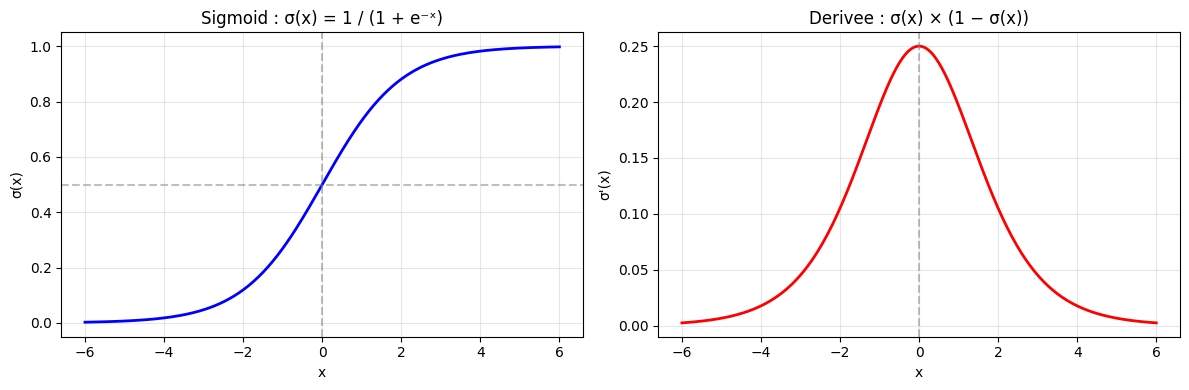

In [33]:
# Visualisation de la sigmoid et sa derivee
x_sig = np.linspace(-6, 6, 300)
y_sig = sigmoid(x_sig)
y_deriv = sigmoid_derivative(sigmoid(x_sig))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(x_sig, y_sig, "b-", linewidth=2)
ax1.axhline(y=0.5, color="gray", linestyle="--", alpha=0.5)
ax1.axvline(x=0, color="gray", linestyle="--", alpha=0.5)
ax1.set_title("Sigmoid : σ(x) = 1 / (1 + e⁻ˣ)")
ax1.set_xlabel("x")
ax1.set_ylabel("σ(x)")
ax1.set_ylim(-0.05, 1.05)
ax1.grid(True, alpha=0.3)

ax2.plot(x_sig, y_deriv, "r-", linewidth=2)
ax2.axvline(x=0, color="gray", linestyle="--", alpha=0.5)
ax2.set_title("Derivee : σ(x) × (1 − σ(x))")
ax2.set_xlabel("x")
ax2.set_ylabel("σ'(x)")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [34]:
W1 = np.random.randn(2, 3) * 0.5
b1 = np.zeros((1, 3))


W2 = np.random.randn(3, 1) * 0.5
b2 = np.zeros((1, 1))

In [35]:
learning_rate = 0.5
epochs = 10000
loss_history = []

for epoch in range(epochs):
    # Forward propagation
    Z1 = X @ W1 + b1
    A1 = sigmoid(Z1)
    Z2 = A1 @ W2 + b2
    A2 = sigmoid(Z2)

    loss = mse_loss(y, A2)
    loss_history.append(loss)

    # Backpropagation
    m = X.shape[0]
    dZ2 = (A2 - y) * sigmoid_derivative(A2)
    dW2 = (A1.T @ dZ2) / m
    db2 = np.sum(dZ2, axis=0, keepdims=True) / m

    dZ1 = (dZ2 @ W2.T) * sigmoid_derivative(A1)
    dW1 = (X.T @ dZ1) / m
    db1 = np.sum(dZ1, axis=0, keepdims=True) / m

    # Mise a jour par descente de gradient
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1

    if epoch % 1000 == 0:
        print(f"epoch={epoch:5d} loss={loss:.6f}")

epoch=    0 loss=0.251398
epoch= 1000 loss=0.250145
epoch= 2000 loss=0.249817
epoch= 3000 loss=0.248310
epoch= 4000 loss=0.219554
epoch= 5000 loss=0.123246
epoch= 6000 loss=0.024063
epoch= 7000 loss=0.009186
epoch= 8000 loss=0.005270
epoch= 9000 loss=0.003606


In [36]:
predictions = (A2 > 0.5).astype(int)

print("Sorties brutes :")
print(np.round(A2, 4))

print("\nPredictions binaires :")
print(predictions.T)

print("\nCibles attendues :")
print(y.T)

print("\nTout correct !" if np.array_equal(predictions, y) else "\nErreurs dans les predictions.")

Sorties brutes :
[[0.0295]
 [0.9504]
 [0.9453]
 [0.0672]]

Predictions binaires :
[[0 1 1 0]]

Cibles attendues :
[[0 1 1 0]]

Tout correct !


## Visualisation

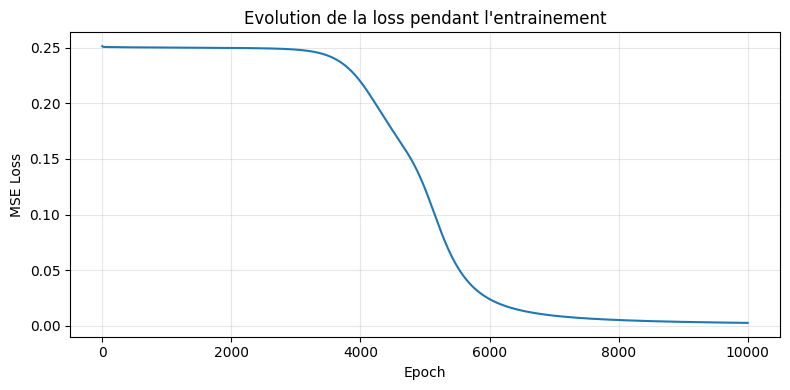

In [37]:
# Courbe de loss
plt.figure(figsize=(8, 4))
plt.plot(loss_history)
plt.title("Evolution de la loss pendant l'entrainement")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

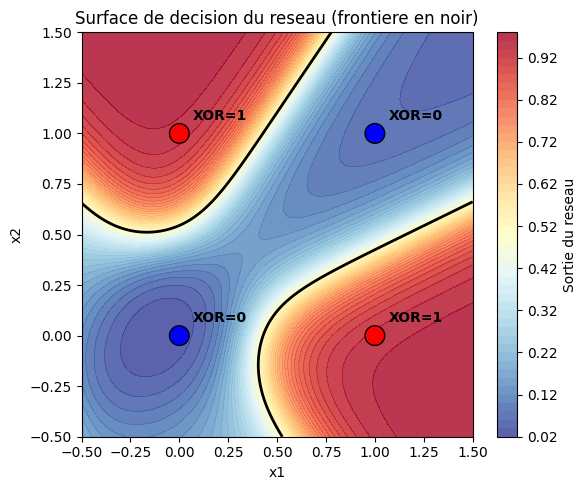

In [38]:
# Surface de decision du reseau
resolution = 200
x_min, x_max = -0.5, 1.5
y_min, y_max = -0.5, 1.5

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, resolution),
    np.linspace(y_min, y_max, resolution)
)
grid = np.c_[xx.ravel(), yy.ravel()]

# Forward pass sur la grille
Z1_grid = grid @ W1 + b1
A1_grid = sigmoid(Z1_grid)
Z2_grid = A1_grid @ W2 + b2
A2_grid = sigmoid(Z2_grid)

zz = A2_grid.reshape(xx.shape)

plt.figure(figsize=(6, 5))
plt.contourf(xx, yy, zz, levels=50, cmap="RdYlBu_r", alpha=0.8)
plt.colorbar(label="Sortie du reseau")
plt.contour(xx, yy, zz, levels=[0.5], colors="black", linewidths=2)

# Points d'entrainement
colors = ["blue" if yi == 0 else "red" for yi in y.ravel()]
plt.scatter(X[:, 0], X[:, 1], c=colors, s=200, edgecolors="black", zorder=5)
for i, (xi, yi) in enumerate(zip(X, y.ravel())):
    plt.annotate(f"XOR={yi}", (xi[0], xi[1]), textcoords="offset points",
                 xytext=(10, 10), fontsize=10, fontweight="bold")

plt.title("Surface de decision du reseau (frontiere en noir)")
plt.xlabel("x1")
plt.ylabel("x2")
plt.tight_layout()
plt.show()

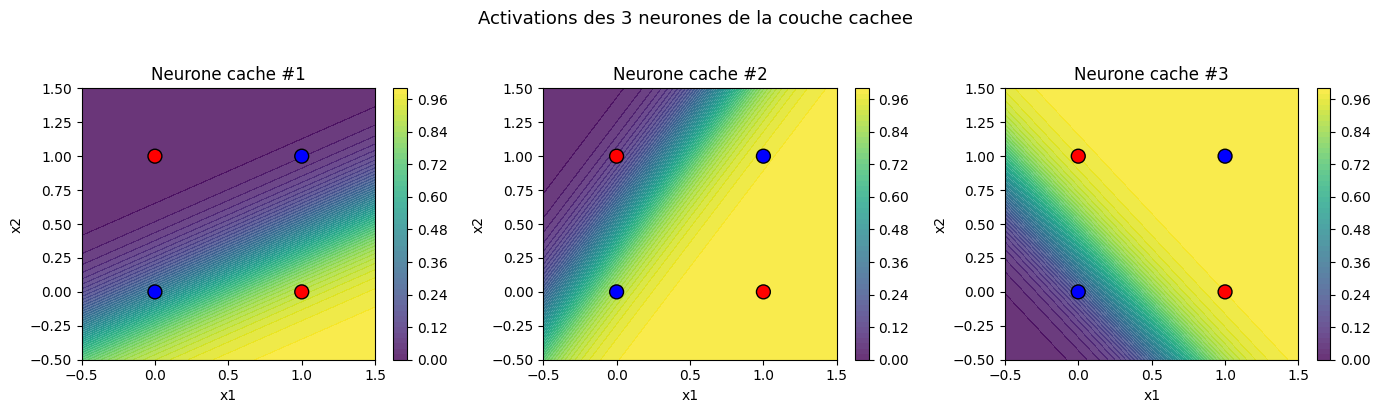

In [39]:
# Activations de la couche cachee
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for i in range(3):
    Z1_grid = grid @ W1 + b1
    A1_grid = sigmoid(Z1_grid)
    zz_neuron = A1_grid[:, i].reshape(xx.shape)

    ax = axes[i]
    im = ax.contourf(xx, yy, zz_neuron, levels=50, cmap="viridis", alpha=0.8)
    ax.scatter(X[:, 0], X[:, 1], c=colors, s=100, edgecolors="black", zorder=5)
    ax.set_title(f"Neurone cache #{i+1}")
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    fig.colorbar(im, ax=ax)

plt.suptitle("Activations des 3 neurones de la couche cachee", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()